# DeepLense Multi-Class Classification — GSoC 2026
 
**Objective:**
Classify gravitational lensing images into three categories:
- No Substructure (`no`)
- Subhalo Substructure (`sphere`)
- Vortex Substructure (`vort`)
 
**Dataset Expectation:**
- Input: Preprocessed images (see below for download instructions)
- Format: Standard image arrays, 3 classes, balanced split (90% train, 10% validation)
- Download: See next cell for Google Drive link and extraction steps
 
**Model Approach:**
- ResNet18 backbone (pretrained on ImageNet) with custom classification head
- Data augmentation: flips, normalization
- Loss: CrossEntropy with Adam optimizer
- Best model checkpointing and reproducibility (fixed seed)
 
**Outputs Produced:**
- Confusion matrix
- Multi-class ROC curves and AUC scores (OvR)
- Training/validation loss and accuracy curves
 
**How to Rerun:**
1. Open in Colab or Jupyter (GPU recommended)
2. Run all cells in order (dataset will be downloaded automatically)
3. Outputs will appear inline; model weights are loaded from `model_weights_test_1.pth` for evaluation
 
> For details on each artifact, see the folder README.

---
## 0. Environment Setup

Install dependencies and download the dataset from Google Drive.

In [1]:
# Install required packages (most are pre-installed on Colab)
!pip install -q gdown scikit-learn seaborn tqdm

In [2]:
import gdown
import zipfile
import os

# Download the dataset ZIP from Google Drive
FILE_ID = '1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ'
ZIP_PATH = '/content/dataset.zip'
DATA_ROOT = '/content/data/dataset'

if not os.path.exists(DATA_ROOT):
    print('Downloading dataset...')
    gdown.download(id=FILE_ID, output=ZIP_PATH, quiet=False)

    print('Extracting...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('/content/data')

    # Clean up the ZIP to save disk space
    os.remove(ZIP_PATH)
    print('Done!')
else:
    print('Dataset already exists, skipping download.')

# Verify the directory structure
for split in ['train', 'val']:
    for cls in ['no', 'sphere', 'vort']:
        d = os.path.join(DATA_ROOT, split, cls)
        n = len([f for f in os.listdir(d) if f.endswith('.npy')])
        print(f'  {split}/{cls}: {n} files')

Downloading...
From (original): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ
From (redirected): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ&confirm=t&uuid=e9fd837d-f3e8-4b65-b706-57d0de001dfd
To: /content/dataset.zip
100%|██████████| 1.13G/1.13G [00:12<00:00, 89.7MB/s]


Extracting...
Done!
  train/no: 10000 files
  train/sphere: 10000 files
  train/vort: 10000 files
  val/no: 2500 files
  val/sphere: 2500 files
  val/vort: 2500 files


---
## 1. Imports & Configuration

In [3]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import (
    roc_curve, auc, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize

# ── Reproducibility ──────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Hyperparameters ──────────────────────────────────────────────
BATCH_SIZE    = 128   # larger batch for T4 GPU
NUM_EPOCHS    = 25
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4
NUM_CLASSES   = 3
IMG_SIZE      = 150   # native resolution of the dataset
RESIZE        = 224   # ResNet expected input size

# ── Paths ────────────────────────────────────────────────────────
DATA_ROOT = '/content/data/dataset'
SAVE_DIR  = '/content/outputs'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Device ───────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('  ⚠️  No GPU detected! Go to Runtime → Change runtime type → T4 GPU')

Using device: cuda
  GPU: Tesla T4
  Memory: 15.6 GB


---
## 2. Data Preparation

The dataset consists of `.npy` files with shape `(1, 150, 150)` (single-channel grayscale), already min-max normalized to [0, 1].

**Strategy:**
- **Preload all images into RAM** as a single tensor (\~3.4 GB) to eliminate slow per-file disk I/O during training.
- Merge the existing `train/` and `val/` folders into one pool.
- Re-split with a strict **90/10** train-test ratio.
- Apply data augmentation (random rotation, flips, crops) to the training set.
- Only resize for the test set.

In [4]:
# ── Class mapping ───────────────────────────────────────────────
CLASS_NAMES = ['no', 'sphere', 'vort']
CLASS_LABELS = {
    'no':     0,  # No substructure
    'sphere': 1,  # Subhalo substructure
    'vort':   2,  # Vortex substructure
}
LABEL_NAMES = {
    0: 'No Substructure',
    1: 'Subhalo (Sphere)',
    2: 'Vortex',
}

In [5]:
# ── Preload ALL images into RAM ──────────────────────────────────
# This takes ~1-2 min but makes each training epoch 10x faster
# by eliminating per-file disk I/O.

all_images = []
all_labels = []

for split in ['train', 'val']:
    for cls_name, cls_id in CLASS_LABELS.items():
        cls_dir = os.path.join(DATA_ROOT, split, cls_name)
        npy_files = sorted(glob.glob(os.path.join(cls_dir, '*.npy')))
        print(f'Loading {split}/{cls_name}: {len(npy_files)} files...', end=' ')
        for f in tqdm(npy_files, desc=f'{split}/{cls_name}', leave=False):
            img = np.load(f).astype(np.float32)  # (1, 150, 150)
            all_images.append(img)
            all_labels.append(cls_id)
        print('✓')

# Stack into single numpy arrays
all_images = np.stack(all_images, axis=0)  # (N, 1, 150, 150)
all_labels = np.array(all_labels, dtype=np.int64)  # (N,)

print(f'\nPreloaded: {all_images.shape[0]} images')
print(f'Shape: {all_images.shape}, dtype: {all_images.dtype}')
print(f'RAM usage: {all_images.nbytes / 1e9:.2f} GB')

for cls_id, cls_display in LABEL_NAMES.items():
    count = (all_labels == cls_id).sum()
    print(f'  Class {cls_id} ({cls_display}): {count}')

Loading train/no: 10000 files... 

train/no:   0%|          | 0/10000 [00:00<?, ?it/s]

✓
Loading train/sphere: 10000 files... 

train/sphere:   0%|          | 0/10000 [00:00<?, ?it/s]

✓
Loading train/vort: 10000 files... 

...

✓
Loading val/sphere: 2500 files... 

val/sphere:   0%|          | 0/2500 [00:00<?, ?it/s]

✓
Loading val/vort: 2500 files... 

val/vort:   0%|          | 0/2500 [00:00<?, ?it/s]

✓

Preloaded: 37500 images
Shape: (37500, 1, 150, 150), dtype: float32
RAM usage: 3.38 GB
  Class 0 (No Substructure): 12500
  Class 1 (Subhalo (Sphere)): 12500
  Class 2 (Vortex): 12500


In [6]:
# ── 90/10 train-test split ──────────────────────────────────────
indices = np.arange(len(all_labels))
np.random.shuffle(indices)

split_idx = int(0.9 * len(indices))
train_idx = indices[:split_idx]
test_idx  = indices[split_idx:]

train_images = all_images[train_idx]  # (N_train, 1, 150, 150)
train_labels = all_labels[train_idx]
test_images  = all_images[test_idx]
test_labels  = all_labels[test_idx]

# Free the combined array to save RAM
del all_images, all_labels, indices
import gc; gc.collect()

print(f'Train samples: {len(train_images)}')
print(f'Test  samples: {len(test_images)}')
print(f'Split ratio:   {len(train_images)/(len(train_images)+len(test_images))*100:.1f}% / '
      f'{len(test_images)/(len(train_images)+len(test_images))*100:.1f}%')

Train samples: 33750
Test  samples: 3750
Split ratio:   90.0% / 10.0%


In [7]:
class LensingDataset(Dataset):
    """
    In-memory PyTorch Dataset for gravitational lensing images.
    All data is preloaded in RAM as numpy arrays for fast access.
    """

    def __init__(self, images, labels, transform=None):
        """
        Args:
            images    (np.ndarray): Shape (N, 1, 150, 150), float32.
            labels    (np.ndarray): Shape (N,), int64.
            transform (callable)  : Optional torchvision transform.
        """
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.images[idx])  # (1, 150, 150)
        img = img.repeat(3, 1, 1)                 # (3, 150, 150) for pretrained ResNet

        if self.transform:
            img = self.transform(img)

        label = int(self.labels[idx])
        return img, label

In [8]:
# ── Data augmentation transforms ────────────────────────────────
# Training: augmentation to prevent overfitting
train_transform = T.Compose([
    T.RandomRotation(degrees=30),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomResizedCrop(size=RESIZE, scale=(0.8, 1.0)),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# Testing: deterministic resize only
test_transform = T.Compose([
    T.Resize((RESIZE, RESIZE)),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# ── Create datasets ─────────────────────────────────────────────
train_dataset = LensingDataset(train_images, train_labels, transform=train_transform)
test_dataset  = LensingDataset(test_images,  test_labels,  transform=test_transform)

print(f'Train dataset size: {len(train_dataset)}')
print(f'Test  dataset size: {len(test_dataset)}')

# ── Create data loaders ──────────────────────────────────────────
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, persistent_workers=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True, persistent_workers=True
)

print(f'Train loader: {len(train_loader)} batches of {BATCH_SIZE}')
print(f'Test  loader: {len(test_loader)} batches of {BATCH_SIZE}')

Train dataset size: 33750
Test  dataset size: 3750
Train loader: 264 batches of 128
Test  loader: 30 batches of 128


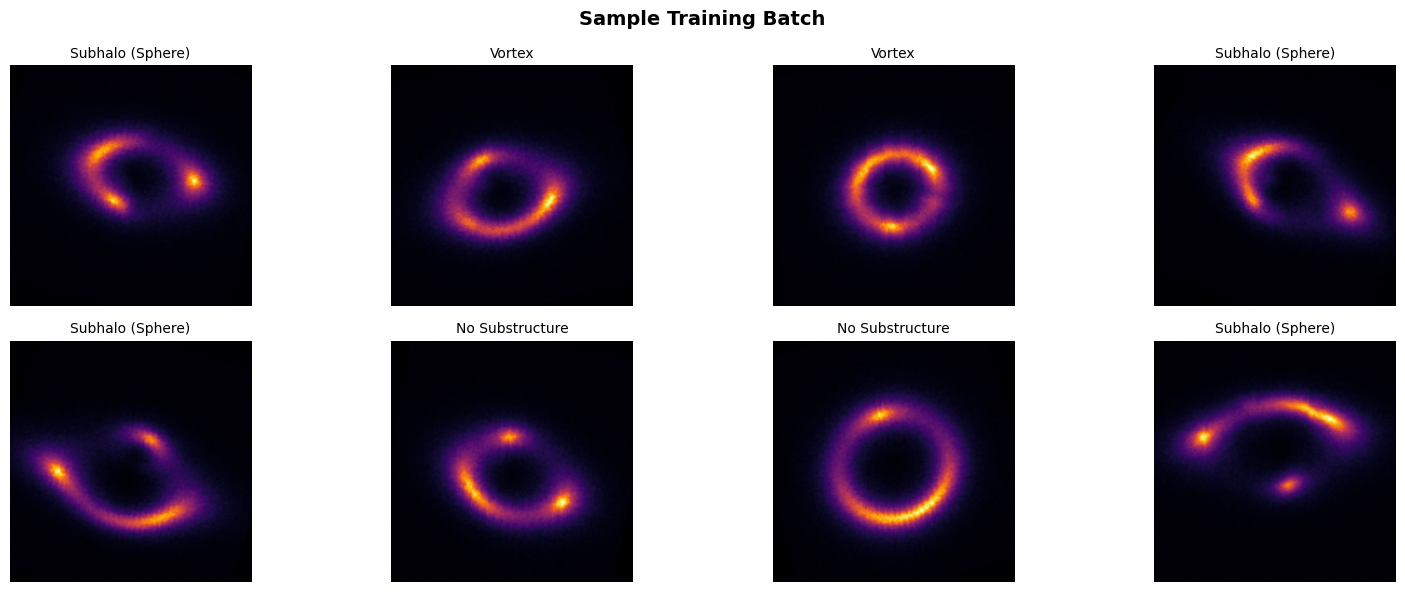

In [9]:
# ── Visualize a sample batch ─────────────────────────────────────
def show_batch(loader, n=8):
    """Display the first n images from a batch."""
    images, labels = next(iter(loader))
    fig, axes = plt.subplots(2, n // 2, figsize=(16, 6))
    for i, ax in enumerate(axes.flat):
        if i >= n:
            break
        # Undo normalization for display: img = img * 0.5 + 0.5
        img = images[i][0].numpy() * 0.5 + 0.5  # take first channel
        ax.imshow(img, cmap='inferno')
        ax.set_title(LABEL_NAMES[labels[i].item()], fontsize=10)
        ax.axis('off')
    plt.suptitle('Sample Training Batch', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_batch(train_loader)

---
## 3. Model Architecture

We use **ResNet18** pretrained on ImageNet. The final fully connected layer is replaced to output 3 classes.

Since the lensing images are single-channel (grayscale), we repeat them to 3 channels in the Dataset class to match the pretrained model's expected input.

In [10]:
def build_model(num_classes=3, pretrained=True):
    """
    Build a ResNet18 model with pretrained ImageNet weights.
    The final FC layer is replaced to output `num_classes` logits.
    """
    if pretrained:
        weights = ResNet18_Weights.IMAGENET1K_V1
        model = resnet18(weights=weights)
    else:
        model = resnet18(weights=None)

    # Replace the final fully connected layer
    in_features = model.fc.in_features  # 512 for ResNet18
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes)
    )

    return model


model = build_model(NUM_CLASSES, pretrained=True).to(device)

# Verify model output shape
dummy = torch.randn(2, 3, RESIZE, RESIZE).to(device)
out = model(dummy)
print(f'Model output shape: {out.shape}  (expected: [2, {NUM_CLASSES}])')

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 121MB/s]


Model output shape: torch.Size([2, 3])  (expected: [2, 3])
Total parameters:     11,178,051
Trainable parameters: 11,178,051


---
## 4. Training Loop

- **Loss**: CrossEntropyLoss (standard for multi-class classification)
- **Optimizer**: Adam with weight decay
- **Scheduler**: ReduceLROnPlateau (reduces LR when validation loss plateaus)
- **Checkpointing**: Save model weights when validation loss reaches a new minimum

In [11]:
# ── Loss, Optimizer, Scheduler ──────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.1, patience=5
)

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train the model for one epoch. Returns average loss and accuracy."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc='  Training', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate the model. Returns average loss and accuracy."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc='  Evaluating', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [13]:
# ── Training loop ───────────────────────────────────────────────
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [],   'val_acc': []
}

best_val_loss = float('inf')
best_epoch = 0
best_model_path = os.path.join(SAVE_DIR, 'best_model.pth')

print(f'Starting training for {NUM_EPOCHS} epochs on {device}...')
print('=' * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    print(f'\nEpoch {epoch}/{NUM_EPOCHS}')

    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    # Validate (using the test set as validation during training)
    val_loss, val_acc = evaluate(
        model, test_loader, criterion, device
    )

    # Update scheduler
    scheduler.step(val_loss)

    # Record history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Print metrics
    current_lr = optimizer.param_groups[0]['lr']
    print(f'  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
    print(f'  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}')
    print(f'  LR: {current_lr:.2e}')

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), best_model_path)
        print(f'  ✓ Best model saved (val_loss: {val_loss:.4f})')

print(f'\n{"=" * 60}')
print(f'Training complete! Best model from epoch {best_epoch} '
      f'(val_loss: {best_val_loss:.4f})')
print(f'Model saved to: {best_model_path}')

Starting training for 25 epochs on cuda...

Epoch 1/25


  Training:   0%|          | 0/264 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

  Train Loss: 1.0183 | Train Acc: 0.4460
  Val   Loss: 1.1699 | Val   Acc: 0.5605
  LR: 1.00e-03
  ✓ Best model saved (val_loss: 1.1699)

Epoch 2/25


  Training:   0%|          | 0/264 [00:00<?, ?it/s]

...

  Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

  Train Loss: 0.1529 | Train Acc: 0.9469
  Val   Loss: 0.1193 | Val   Acc: 0.9587
  LR: 1.00e-04
  ✓ Best model saved (val_loss: 0.1193)

Epoch 25/25


  Training:   0%|          | 0/264 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

  Train Loss: 0.1504 | Train Acc: 0.9462
  Val   Loss: 0.1180 | Val   Acc: 0.9581
  LR: 1.00e-04
  ✓ Best model saved (val_loss: 0.1180)

Training complete! Best model from epoch 25 (val_loss: 0.1180)
Model saved to: /content/outputs/best_model.pth


---
## 5. Training Curves

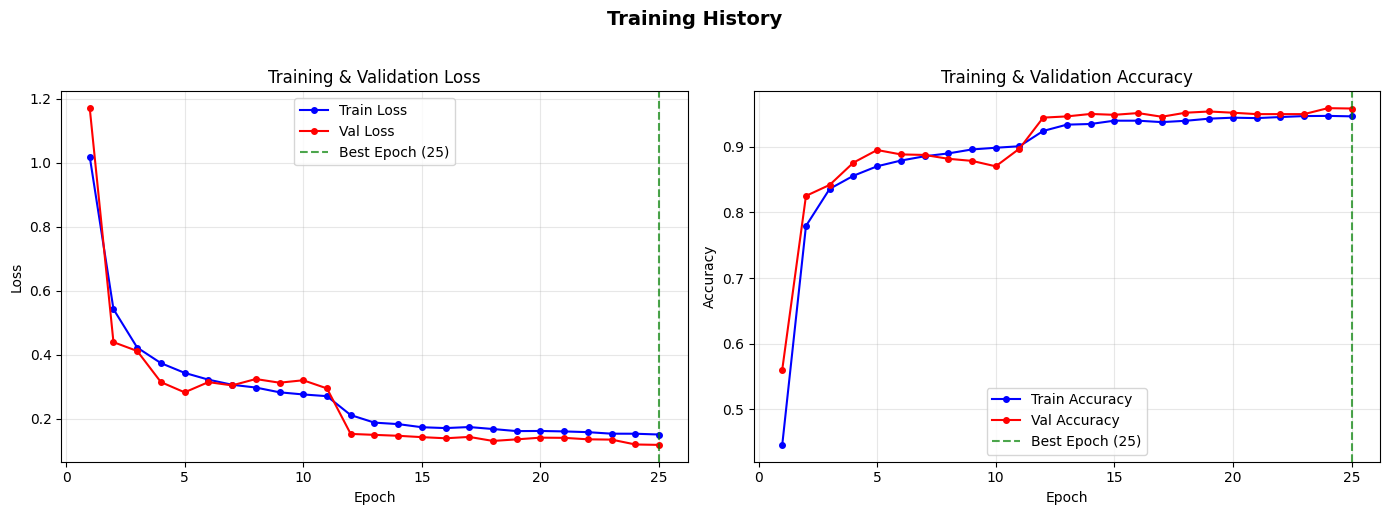

Training curves saved to: /content/outputs/training_curves.png


In [14]:
# ── Plot training curves ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
ax1.plot(epochs_range, history['train_loss'], 'b-o', markersize=4, label='Train Loss')
ax1.plot(epochs_range, history['val_loss'], 'r-o', markersize=4, label='Val Loss')
ax1.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_range, history['train_acc'], 'b-o', markersize=4, label='Train Accuracy')
ax2.plot(epochs_range, history['val_acc'], 'r-o', markersize=4, label='Val Accuracy')
ax2.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training & Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Training curves saved to: {os.path.join(SAVE_DIR, "training_curves.png")}')

---
## 6. Evaluation & Metrics

Load the best model and evaluate on the test set:
- Classification report (precision, recall, F1-score)
- Confusion matrix
- ROC curves with AUC scores (One-vs-Rest strategy)

In [15]:
# ── Load best model ──────────────────────────────────────────────
model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))
model.eval()
print(f'Loaded best model from epoch {best_epoch}')

# ── Collect predictions ──────────────────────────────────────────
all_probs = []
all_preds = []
all_true = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Inference'):
        images = images.to(device, non_blocking=True)
        outputs = model(images)

        # Softmax probabilities for ROC
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_probs.append(probs)
        all_preds.append(preds)
        all_true.append(labels.numpy())

all_probs = np.concatenate(all_probs, axis=0)  # (N, 3)
all_preds = np.concatenate(all_preds, axis=0)   # (N,)
all_true  = np.concatenate(all_true, axis=0)     # (N,)

print(f'\nTest samples evaluated: {len(all_true)}')

Loaded best model from epoch 25


Inference:   0%|          | 0/30 [00:00<?, ?it/s]


Test samples evaluated: 3750


In [16]:
# ── Classification Report ────────────────────────────────────────
target_names = [LABEL_NAMES[i] for i in range(NUM_CLASSES)]
report = classification_report(all_true, all_preds, target_names=target_names)
print('Classification Report:')
print(report)

Classification Report:
                  precision    recall  f1-score   support

 No Substructure       0.93      1.00      0.96      1207
Subhalo (Sphere)       0.97      0.92      0.94      1245
          Vortex       0.98      0.96      0.97      1298

        accuracy                           0.96      3750
       macro avg       0.96      0.96      0.96      3750
    weighted avg       0.96      0.96      0.96      3750



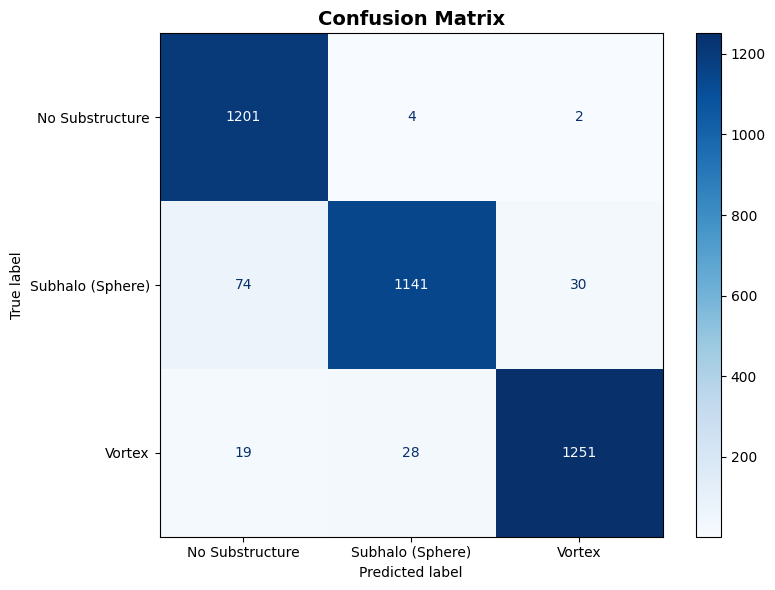

Confusion matrix saved to: /content/outputs/confusion_matrix.png


In [17]:
# ── Confusion Matrix ─────────────────────────────────────────────
cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Confusion matrix saved to: {os.path.join(SAVE_DIR, "confusion_matrix.png")}')

---
## 7. ROC Curves & AUC Scores

Using a **One-vs-Rest (OvR)** strategy to compute per-class ROC curves and AUC scores.

In [18]:
# ── Binarize labels for One-vs-Rest ──────────────────────────────
all_true_bin = label_binarize(all_true, classes=[0, 1, 2])  # (N, 3)

# ── Compute per-class ROC curve and AUC ──────────────────────────
fpr = {}
tpr = {}
roc_auc = {}

colors = ['#e74c3c', '#3498db', '#2ecc71']  # Red, Blue, Green

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(all_true_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    print(f'Class {i} ({LABEL_NAMES[i]}): AUC = {roc_auc[i]:.4f}')

# ── Macro-average AUC ────────────────────────────────────────────
macro_auc = np.mean(list(roc_auc.values()))
print(f'\nMacro-Average AUC: {macro_auc:.4f}')

Class 0 (No Substructure): AUC = 0.9960
Class 1 (Subhalo (Sphere)): AUC = 0.9918
Class 2 (Vortex): AUC = 0.9975

Macro-Average AUC: 0.9951


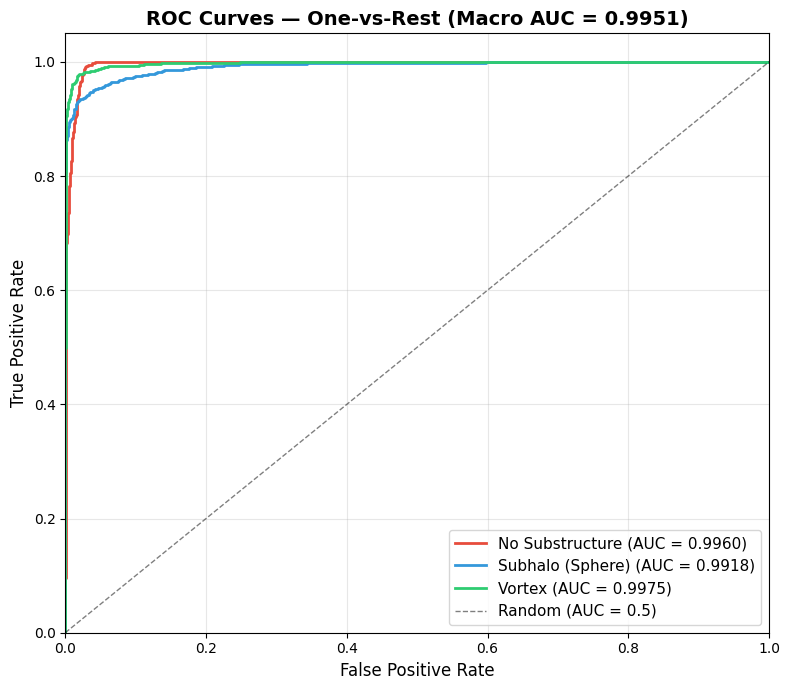

ROC curves saved to: /content/outputs/roc_curves.png


In [19]:
# ── Plot ROC Curves ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

for i in range(NUM_CLASSES):
    ax.plot(
        fpr[i], tpr[i],
        color=colors[i], linewidth=2,
        label=f'{LABEL_NAMES[i]} (AUC = {roc_auc[i]:.4f})'
    )

# Diagonal reference line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.5)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(
    f'ROC Curves — One-vs-Rest (Macro AUC = {macro_auc:.4f})',
    fontsize=14, fontweight='bold'
)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'ROC curves saved to: {os.path.join(SAVE_DIR, "roc_curves.png")}')

---
## 8. Download Outputs

Download the trained model weights and plots from Colab.

In [20]:
# ── Download outputs from Colab ──────────────────────────────────
from google.colab import files

print('Downloading output files...')
for fname in ['best_model.pth', 'training_curves.png', 'confusion_matrix.png', 'roc_curves.png']:
    fpath = os.path.join(SAVE_DIR, fname)
    if os.path.exists(fpath):
        files.download(fpath)
        print(f'  ✓ {fname}')
    else:
        print(f'  ✗ {fname} not found')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ best_model.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✓ confusion_matrix.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ roc_curves.png


---
## Summary

| Step | Detail |
|------|--------|
| **Data** | 37,500 images (3 classes × 12,500), 90/10 split, augmented with rotations/flips/crops |
| **Model** | ResNet18 with ImageNet pretrained weights, modified FC → 3 classes |
| **Training** | CrossEntropyLoss, Adam (lr=1e-3), ReduceLROnPlateau, best-model checkpointing |
| **Evaluation** | Per-class ROC/AUC (One-vs-Rest), confusion matrix, classification report |
| **Outputs** | `best_model.pth`, `roc_curves.png`, `confusion_matrix.png`, `training_curves.png` |